In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
from langgraph.graph import StateGraph, MessagesState, START, END
groq_api_key = os.getenv("GROQ_API_KEY")
# print(groq_api_key)

C:\Users\ybalasaraswa\OneDrive - OpenText\Desktop\deep learning\LangChain\.myvenv\Lib\site-packages\langchain_core\_api\deprecation.py:26: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
# LangSmith Tracking
if os.getenv("LANGCHAIN_API_KEY"):
    os.environ['LANGCHAIN_API_KEY'] = os.getenv("LANGCHAIN_API_KEY")
    os.environ['LANGCHAIN_TRACING_V2'] = 'true'
    os.environ['LANGCHAIN_PROJECT'] = "LangGraph Demo"

In [4]:
from langchain_groq import ChatGroq

llm = ChatGroq(api_key=groq_api_key, model="openai/gpt-oss-120b")

C:\Users\ybalasaraswa\OneDrive - OpenText\Desktop\deep learning\LangChain\.myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### ChatBot using LangGraph

In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.graph.message import add_messages


In [6]:
class State(TypedDict):
    """
    Messages have the type ""List"" the add_messages function
     in the annotations defines how the state key should be updated
     in this case it updates messages to the list rather than overriding them
    """
    messages: Annotated[list[MessagesState], add_messages]

In [7]:
graph_builder = StateGraph(State)
graph_builder

In [8]:
def chatBot(state: State):
    return {
        "messages": llm.invoke(state['messages'])
    }

In [9]:
graph_builder.add_node("chatbot", chatBot)

In [10]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [11]:
graph = graph_builder.compile()

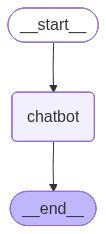

In [12]:
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization is not supported in this environment.")

In [13]:
while True:
  user_input=input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({'messages':("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value["messages"].content)

dict_values([{'messages': AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hello". We need to respond appropriately. It\'s a greeting. We can respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 73, 'total_tokens': 113, 'completion_time': 0.085760548, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.002882233, 'prompt_tokens_details': None, 'queue_time': 0.045574345, 'total_time': 0.088642781}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019c6bc9-eed3-7650-ba4e-accb1f106059-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 40, 'total_tokens': 113, 'output_token_details': {'reasoning': 22}})}])
content='Hello! How can I help you today?' additional_kwargs={'reasoning_content':

### latest way to use LangGraph with less boilerplate

In [13]:
from langgraph.graph import StateGraph, MessagesState, START, END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})